# Práctica 1 — Modelo de pérdidas del ramo de Incendios
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Facultad de Ciencias, UNAM

**Equipo 08 · Ramo: Incendios**

---
Con la cartera de nuestro ramo, modelamos la **severidad** y la
**frecuencia**, simulamos la **pérdida agregada S** y sacamos de ahí la **prima pura preliminar**
del producto.

---
## 0. Entorno

In [2]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

np.random.seed(8)   
plt.rcParams["figure.figsize"] = (9, 4)
print("✓ Entorno listo")

✓ Entorno listo


---
## 1. Cargar datos y explorar las variables de interés

Para esta práctica **solo nos importan algunas columnas**
(la agregada, sin factores de riesgo):

| Necesito para... | Variable | Qué es |
|---|---|---|
| Frecuencia | `num_siniestros`, `exposicion` | número de siniestros de la póliza y años-póliza expuestos |
| Severidad | `monto_promedio_siniestro` | monto ground-up (daño real) promedio por siniestro de la póliza |
| Transformar la póliza | `deducible`, `coaseguro`, `suma_asegurada` | condiciones del contrato, para pasar de severidad real a la que paga la aseguradora |

El resto de columnas (`tipo_inmueble`, `material_construccion`, `uso_inmueble`, `giro`,
`medidas_proteccion`, `antiguedad_inmueble`, `zona`) **existen pero no se usan en esta práctica**:
son los factores de riesgo por póliza que sí vamos a explotar en la Práctica 2 con un GLM.

In [3]:
df = pd.read_parquet("../inputs/cartera.parquet")
print(f"Pólizas: {len(df):,} | Columnas: {len(df.columns)}")
print("\nVariables que usamos en la Práctica 1:")
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")
print("\nNo se usan aquí (factores de riesgo, para el GLM de la Práctica 2):")
print(" ", [c for c in df.columns if c not in
      ["id_poliza","exposicion","num_siniestros","monto_promedio_siniestro",
       "monto_total_siniestros","deducible","coaseguro","suma_asegurada"]])

Pólizas: 30,000 | Columnas: 15

Variables que usamos en la Práctica 1:
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)

No se usan aquí (factores de riesgo, para el GLM de la Práctica 2):
  ['tipo_inmueble', 'material_construccion', 'uso_inmueble', 'giro', 'medidas_proteccion', 'antiguedad_inmueble', 'zona']


% de pólizas con siniestro : 2.81%
Distribución de num_siniestros:
num_siniestros
0    29156
1      814
2       30

Exposición total           : 24,006.2 años-póliza
Exposición por póliza      : media 0.800, rango [0.233, 0.999]

Severidad (monto_promedio_siniestro), solo pólizas con siniestro:
count         844.0
mean      1101539.0
std       3707539.0
min          2022.0
25%         83806.0
50%        260545.0
75%        742485.0
max      65619863.0


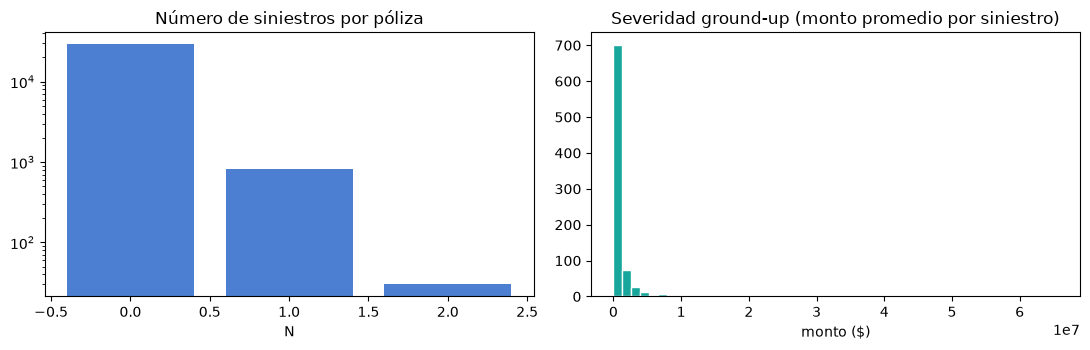

In [4]:
# ─── Exploración enfocada: solo número de siniestros, exposición y monto ───
con = df[df.num_siniestros > 0]                       # pólizas con al menos un siniestro

print(f"% de pólizas con siniestro : {(df.num_siniestros > 0).mean():.2%}")
print(f"Distribución de num_siniestros:\n{df.num_siniestros.value_counts().sort_index().to_string()}")
print(f"\nExposición total           : {df.exposicion.sum():,.1f} años-póliza")
print(f"Exposición por póliza      : media {df.exposicion.mean():.3f}, rango [{df.exposicion.min():.3f}, {df.exposicion.max():.3f}]")
print(f"\nSeveridad (monto_promedio_siniestro), solo pólizas con siniestro:")
print(con.monto_promedio_siniestro.describe().round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
vals, cts = np.unique(df.num_siniestros, return_counts=True)
ax[0].bar(vals, cts, color="#4C7FD1")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N"); ax[0].set_yscale("log")
ax[1].hist(con.monto_promedio_siniestro, bins=50, color="#17A69B", edgecolor="white")
ax[1].set_title("Severidad ground-up (monto promedio por siniestro)"); ax[1].set_xlabel("monto ($)")
plt.tight_layout(); plt.show()

La cartera de Incendios es una cartera de **baja frecuencia** (solo ~2.8% de las
pólizas reportan algún siniestro en el periodo, casi todas con un único siniestro) y **severidad
muy sesgada**: la mediana está muy por debajo de la media, señal de una cola pesada — típico del
ramo, donde la mayoría de los siniestros son daños menores pero unos pocos son pérdidas totales del
inmueble.

---
## 2. Severidad

Para modelar la severidad utilizamos `monto_promedio_siniestro` únicamente en las
pólizas que presentaron al menos un siniestro. Esta variable representa la severidad
**ground-up**, es decir, el monto real del daño antes de aplicar las condiciones de la póliza.

De acuerdo con la guía del ramo, Incendio se caracteriza por una severidad alta y de
cola pesada, ya que pueden presentarse pocos siniestros de montos muy elevados.

Por ello, ajustaremos las distribuciones **Lognormal, Gamma, Weibull y Pareto** y
compararemos su desempeño mediante el **AIC** y el comportamiento de la **cola**.

In [5]:
# ─── Severidad ground-up ────────────────────────────────────────────────

x = con["monto_promedio_siniestro"].dropna().values
x = x[x > 0]

media = x.mean()
mediana = np.median(x)
cv = x.std(ddof=1) / media
razon = media / mediana

print(f"Número de observaciones de severidad : {len(x):,}")
print(f"Media                              : ${media:,.0f}")
print(f"Mediana                            : ${mediana:,.0f}")
print(f"Media / mediana                    : {razon:.2f}")
print(f"Coeficiente de variación           : {cv:.2f}")
print(f"Máximo observado                   : ${x.max():,.0f}")

Número de observaciones de severidad : 844
Media                              : $1,101,539
Mediana                            : $260,545
Media / mediana                    : 4.23
Coeficiente de variación           : 3.37
Máximo observado                   : $65,619,863


### Exploración de la severidad

La severidad presenta un fuerte sesgo hacia la derecha. La media de los siniestros es de aproximadamente $1.10 millones, mientras que la mediana es de alrededor de $260 mil, por lo que la media resulta aproximadamente 4.23 veces mayor que la mediana.

Además, el coeficiente de variación es 3.37 y el monto máximo observado alcanza aproximadamente $65.6 millones. Esto indica una elevada dispersión y la presencia de algunos siniestros de gran magnitud que incrementan considerablemente la media.

Este comportamiento es consistente con el perfil del ramo de Incendio, que se caracteriza por una severidad alta y una cola pesada, debido a que pueden ocurrir pocos siniestros muy costosos e incluso pérdidas totales.

In [7]:
# ─── Ajuste de distribuciones de severidad ──────────────────────────────

def calcular_aic(dist, params, datos):
    log_verosimilitud = np.sum(dist.logpdf(datos, *params))
    k = len(params)
    return 2 * k - 2 * log_verosimilitud


candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto
}

ajustes = {}
resultados = []

for nombre, dist in candidatas.items():

    params = dist.fit(x, floc=0)

    ajustes[nombre] = (dist, params)

    resultados.append({
        "Distribución": nombre,
        "AIC": calcular_aic(dist, params, x)
    })


tabla_aic = pd.DataFrame(resultados)
tabla_aic = tabla_aic.sort_values("AIC").reset_index(drop=True)

tabla_aic["Delta AIC"] = tabla_aic["AIC"] - tabla_aic["AIC"].min()

tabla_aic["AIC"] = tabla_aic["AIC"].round(1)
tabla_aic["Delta AIC"] = tabla_aic["Delta AIC"].round(1)

print(tabla_aic.to_string(index=False))

mejor_aic = tabla_aic.loc[0, "Distribución"]

print(f"\nMejor distribución únicamente por AIC: {mejor_aic}")

Distribución     AIC  Delta AIC
   Lognormal 24309.7        0.0
     Weibull 24460.7      151.0
       Gamma 24648.0      338.3
      Pareto 25385.6     1075.9

Mejor distribución únicamente por AIC: Lognormal


### Comparación mediante AIC

Entre las distribuciones ajustadas, la **Lognormal** presenta el menor valor de AIC
(24309.7), seguida por Weibull, Gamma y Pareto.

Las diferencias de AIC respecto de la Lognormal son amplias, especialmente para Gamma
y Pareto, por lo que la Lognormal ofrece el mejor ajuste global entre las distribuciones
consideradas.

Sin embargo, dado que el ramo de Incendio se caracteriza por una cola pesada, la
selección final no se realizará únicamente con el AIC. También se analizará visualmente
el comportamiento de las distribuciones en la cola.

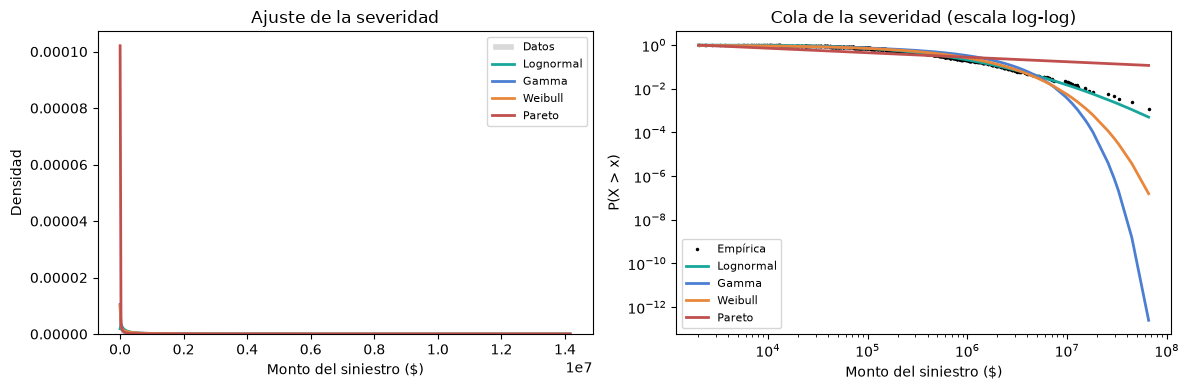

In [8]:
# ─── Diagnóstico gráfico: ajuste y comportamiento de la cola ────────────

colores = {
    "Lognormal": "#17A69B",
    "Gamma": "#4C7FD1",
    "Weibull": "#E8873C",
    "Pareto": "#C0504D"
}

# Percentil 99 para visualizar mejor el cuerpo de los datos
p99 = np.percentile(x, 99)
grid = np.linspace(x.min(), p99, 500)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# ── Histograma + densidades ajustadas ──
ax[0].hist(
    x,
    bins=70,
    density=True,
    range=(x.min(), p99),
    color="#d9d9d9",
    edgecolor="white",
    label="Datos"
)

for nombre, (dist, params) in ajustes.items():
    ax[0].plot(
        grid,
        dist.pdf(grid, *params),
        color=colores[nombre],
        lw=2,
        label=nombre
    )

ax[0].set_title("Ajuste de la severidad")
ax[0].set_xlabel("Monto del siniestro ($)")
ax[0].set_ylabel("Densidad")
ax[0].legend(fontsize=8)


# ── Función de supervivencia: cola ──
xs = np.sort(x)

S_emp = 1 - np.arange(1, len(xs) + 1) / (len(xs) + 1)

ax[1].plot(
    xs,
    S_emp,
    ".",
    color="black",
    markersize=3,
    label="Empírica"
)

for nombre, (dist, params) in ajustes.items():
    ax[1].plot(
        xs,
        dist.sf(xs, *params),
        color=colores[nombre],
        lw=2,
        label=nombre
    )

ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_title("Cola de la severidad (escala log-log)")
ax[1].set_xlabel("Monto del siniestro ($)")
ax[1].set_ylabel("P(X > x)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Selección de la distribución de severidad

La distribución **Lognormal** fue seleccionada para modelar la severidad ground-up
del ramo de Incendio.

Por un lado, presentó el menor AIC (24309.7), con diferencias considerables respecto
a Weibull, Gamma y Pareto, por lo que proporciona el mejor ajuste global entre las
distribuciones consideradas.

Por otro lado, el análisis de la función de supervivencia muestra que la Lognormal
representa mejor el comportamiento de la cola empírica. La Gamma y la Weibull
disminuyen demasiado rápido para los montos elevados, lo que podría subestimar la
probabilidad de siniestros grandes. En contraste, la Pareto presenta una cola
demasiado pesada y sobreestima la probabilidad de pérdidas extremas.

Por lo tanto, considerando conjuntamente el AIC y el comportamiento de la cola,
elegimos la **Lognormal** como modelo de severidad para la cartera de Incendio.

In [9]:
# ─── Distribución seleccionada para la severidad ────────────────────────

mejor = "Lognormal"

dist_sev, pr_sev = ajustes[mejor]

print(f"Distribución seleccionada : {mejor}")
print(f"Parámetros estimados       : {pr_sev}")

Distribución seleccionada : Lognormal
Parámetros estimados       : (np.float64(1.6849641995627767), 0, np.float64(257111.70215221363))


In [10]:
# ─── Medidas del modelo de severidad seleccionado ──────────────────────

media_modelo = dist_sev.mean(*pr_sev)

var99_sev = dist_sev.ppf(0.99, *pr_sev)

tvar99_sev = dist_sev.expect(
    lambda z: z,
    args=pr_sev[:-2],
    loc=pr_sev[-2],
    scale=pr_sev[-1],
    lb=var99_sev,
    conditional=True
)

print(f"Media empírica        : ${x.mean():,.0f}")
print(f"Media del modelo      : ${media_modelo:,.0f}")
print(f"VaR 99% severidad     : ${var99_sev:,.0f}")
print(f"TVaR 99% severidad    : ${tvar99_sev:,.0f}")

Media empírica        : $1,101,539
Media del modelo      : $1,063,226
VaR 99% severidad     : $12,956,120
TVaR 99% severidad    : $21,950,477


c:\Users\Dania\anaconda3\envs\MASDFR\Lib\site-packages\scipy\stats\_distn_infrastructure.py:3047: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dub = integrate.quad(fun, d, ub, **kwds)[0]


### Efecto de las condiciones de la póliza

Hasta este punto se modeló la severidad **ground-up**, es decir, el daño real ocasionado
por el siniestro. Sin embargo, este monto no necesariamente coincide con lo que paga
la aseguradora.

Para obtener la severidad a cargo de la compañía se aplican las condiciones de cada
póliza: deducible, coaseguro y suma asegurada.

In [11]:
# ─── Transformación de la severidad según la póliza ─────────────────────

def transformar_severidad(x, deducible, coaseguro, suma_asegurada):

    # Se resta el deducible
    despues_deducible = np.maximum(x - deducible, 0)

    # El asegurado absorbe la proporción indicada por el coaseguro
    despues_coaseguro = despues_deducible * (1 - coaseguro)

    # La aseguradora no puede pagar más que la suma asegurada
    pago_aseguradora = np.minimum(
        despues_coaseguro,
        suma_asegurada
    )

    return pago_aseguradora


pagado = transformar_severidad(
    con["monto_promedio_siniestro"].values,
    con["deducible"].values,
    con["coaseguro"].values,
    con["suma_asegurada"].values
)

media_ground = x.mean()
media_pagada = pagado.mean()

reduccion = 1 - media_pagada / media_ground

print(f"Severidad media ground-up        : ${media_ground:,.0f}")
print(f"Pago medio de la aseguradora     : ${media_pagada:,.0f}")
print(f"Reducción por condiciones póliza : {reduccion:.1%}")
print(f"Siniestros con pago igual a cero : {(pagado == 0).mean():.1%}")

Severidad media ground-up        : $1,101,539
Pago medio de la aseguradora     : $521,373
Reducción por condiciones póliza : 52.7%
Siniestros con pago igual a cero : 16.6%


### Efecto de las condiciones de la póliza

La severidad media **ground-up**, es decir, el daño real antes de aplicar las
condiciones del contrato, es de aproximadamente **$1,101,539** por siniestro.

Después de aplicar el deducible, el coaseguro y la suma asegurada, el pago medio
de la aseguradora disminuye a aproximadamente **$521,373**. Esto representa una
reducción de **52.7%** respecto de la severidad ground-up, por lo que la compañía
paga en promedio alrededor del **47.3% del daño original**.

Además, aproximadamente **16.6% de los siniestros generan un pago igual a cero**,
principalmente porque el monto del daño no supera el deducible correspondiente.

Estos resultados muestran que las condiciones de la póliza tienen un efecto
importante sobre la severidad asumida por la aseguradora: el deducible elimina
parte de los siniestros pequeños, el coaseguro reduce el monto que queda a cargo
de la compañía y la suma asegurada limita las pérdidas de mayor magnitud.

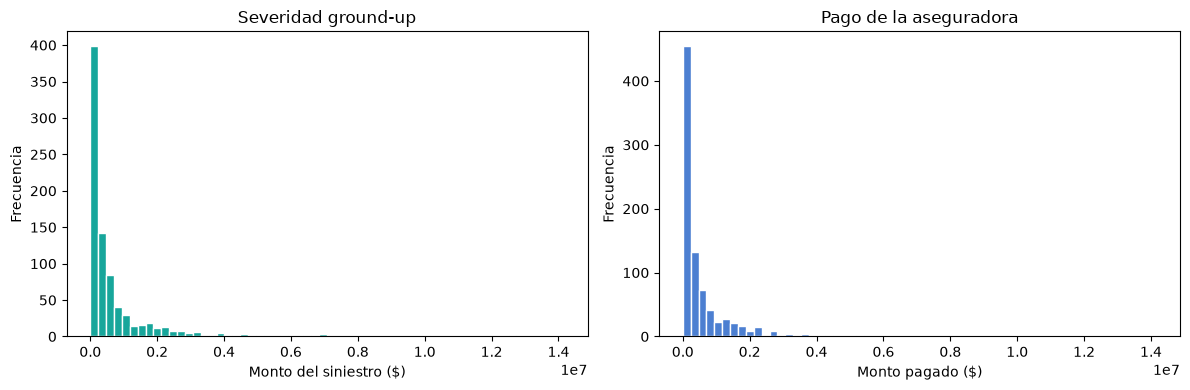

In [12]:
# ─── Ground-up vs pago de la aseguradora ────────────────────────────────

limite = np.percentile(x, 99)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Severidad real
ax[0].hist(
    x,
    bins=60,
    range=(0, limite),
    color="#17A69B",
    edgecolor="white"
)

ax[0].set_title("Severidad ground-up")
ax[0].set_xlabel("Monto del siniestro ($)")
ax[0].set_ylabel("Frecuencia")


# Severidad pagada
ax[1].hist(
    pagado,
    bins=60,
    range=(0, limite),
    color="#4C7FD1",
    edgecolor="white"
)

ax[1].set_title("Pago de la aseguradora")
ax[1].set_xlabel("Monto pagado ($)")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()